In [3]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load dataset
data = pd.read_csv("50_Startups_dataset.csv")

In [5]:

data = data.drop(columns=["Unnamed: 0"])

print(data.head())


   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.30       136897.90        471784.20    New York  192261.93
1  162597.80       151377.69        443898.63  California  191792.16
2  153441.61       101145.65        407934.64     Florida  191050.49
3  144372.51       118671.95        383199.72    New York  182902.09
4  142107.44        91391.87        366168.52     Florida  166188.04


In [6]:
# 1. Separate features and target
# -----------------------------
y = data["Profit"]
X = data.drop(["Profit"], axis=1)

In [7]:
# 2. One-Hot Encode categorical columns
# -----------------------------
X = pd.get_dummies(X, drop_first=True)

print("\nData after One-Hot Encoding:")
print(X.head())


Data after One-Hot Encoding:
   R&D Spend  Administration  Marketing Spend  State_Florida  State_New York
0  165349.30       136897.90        471784.20          False            True
1  162597.80       151377.69        443898.63          False           False
2  153441.61       101145.65        407934.64           True           False
3  144372.51       118671.95        383199.72          False            True
4  142107.44        91391.87        366168.52           True           False


In [9]:
# 3. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# 4. Create & train model
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [11]:
# 5. Model Evaluation
# -----------------------------
print("\nModel Training Score:", model.score(X_train, y_train))
print("Model Testing Score:", model.score(X_test, y_test))


Model Training Score: 0.9537019995248526
Model Testing Score: 0.8987266414328636


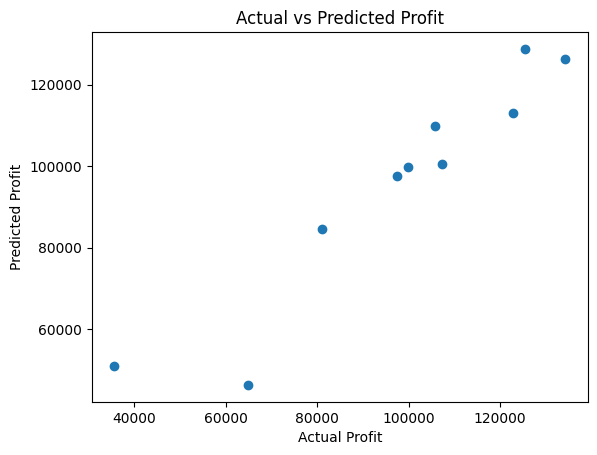

In [12]:
# 6. Visualizing Predictions
# -----------------------------
y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")
plt.show()

In [13]:
# PROFIT CHECKER CODE (Predict profit for new values)
# -------------------------------------------------------

new_data = {
    "R&D Spend": [160000],
    "Administration": [130000],
    "Marketing Spend": [300000],
    "State_Florida": [0],
    "State_New York": [1]
}

new_df = pd.DataFrame(new_data)

# Match columns
new_df = new_df.reindex(columns=X.columns, fill_value=0)

In [14]:
# Predict
predicted_profit = model.predict(new_df)

print("\nPredicted Profit: $", predicted_profit[0])


Predicted Profit: $ 182950.06905907215
